# Face Alignment

## Выбор датасета

В этом проекте мы будем работать с датасетом [CelebA - Original Wild Images](https://mmlab.ie.cuhk.edu.hk/projects/CelebA.html). Обычно, когда говорят про CelebA имеют ввиду его кропнутую и выровненную версию, но мы будем работать с сырой.

![CelebA](https://figures.semanticscholar.org/7df4f96138a4e23492ea96cf921794fc5287ba72/6-Figure4-1.png)

Оригинальная версия датасета весит очень много: ~20 гб. Все картинки нам не будут нужны, достаточно будет ограничиться 10.000+.

Вашим первым заданием будет подготовить себе рабочий датасет. Он будет использован и в следующих заданиях, поэтому подойдите к этому очень ответственно:

- Скачайте себе датасет CelebA In a Wild любым удобным способом;
- Подумайте над тем, по каким критериям лучше всего выбирать картинки. Используйте файл с атрибутами. Обоснуйте свой выбор текстом. В случае, если обоснования выбора датасета не будет, то баллы могут быть снижены. Отнеситесь к этому серьезно: хорошая подготовка данных очень важна;
- Отберите 10.000+ изображений. Можно и больше при желании;
- При помощи атрибутов bbox'а, обрежьте картинки, чтобы на них остались только лица. При желании можно делать дополнительный кроп, так как не везде разметка идеальна, но не нужно сидеть над каждой картинкой отдельно - потратите слишком много времени;
- Сохраните отдельный csv-файл с оригинальными названиями изображений, которые были отобраны в ваш датасет. В дальнейшем он в том числе понадобится для сдачи проекта.

Несколько практических советов:
- Отнеситесь очень ответственно к отбору данных, это важнейшая часть проекта. Заранее лучше закладывайте время на то, что, очень вероятно, вам придется делать отбор заново по ходу осознания всех заданий.
- Если решили делать дополнительный кроп изображений самостоятельно, то имейте ввиду, что ключевые точки лица в атрибутах указаны в начальной системе координат.
- При первичном анализе и отборе данных не работайте в колабе. Простейшую работу с файлами удобнее делать локально на своем компьютере. Это не требует мощного железа и скачивания библиотек. Если все же пользуетесь колабом, то работайте на CPU, чтобы не лишний раз не тратить токены.
- Если есть возможность, то не удаляйте оригинальный датасет с вашего компьютера на период работы над проектом. Да, это лишняя занятая память, но зато при надобности можно будет быстро что-то изменить.
- Загрузите финальный датасет (10.000+ картинок) себе на Google Disk. Это удобнее, чем каждый раз отдельно загружать его себе в колаб сессию.

In [47]:
import matplotlib.pyplot as plt
from pathlib import Path

import os, random, time, cv2
import numpy as np

import pandas as pd
from PIL import Image
from tqdm import tqdm
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torchvision import transforms
from torch.utils.data import random_split

Попробуем получить качественный, разнообразный и хорошо размеченный датасет, который будет содержать лица разных людей, пола, возраста, ракурсов и условий съемки.

Для этого воспользуемся следующими критериями отбора:

1. Использовать только изображения с достаточно крупным лицом - на маленьких лицах теряются детали, ухудшается качество обучения и дальнейшей обработки.

Главный критерий — размер bounding box. Например:
* ширина bbox ≥ 80 px;
* высота bbox ≥ 80 px.

2. Исключить экстремальные ракурсы.

В CelebA нет хорошей разметки yaw/pitch. 
Поэтому лучше использовать Looking Ahead (если есть), либо вообще не фильтровать по позе и оставить разные ракурсы.
Не стоит использовать атрибуты: Big Nose, Big Lips, Pointy Nose,  — они не относятся к ракурсу.
Это сделает датасет более разнообразным.

3. Оставить людей обоих полов.
Использовав аттрибут "Male", сделать примерно 50% Male и 50% Female, чтобы не получить сильный перекос.

4. Оставить людей разных возрастов.

Использовав аттрибут "Young", отфильтровать, например, 70% Young и 30% not Young.
Полностью балансировать не получится, потому что взрослых людей в CelebA намного меньше.


5. Не удалять людей с очками, бородой и т.д.
Наоборот, лучше оставить людей с аттрибутами "Eyeglasses", "Beard", "Mustache", "Hat", - они делают датасет более разнообразным.

6. Удалить совсем плохие изображения. 
Использовать аттрибут "Blurry = -1", если атрибут имеется. Размытые фотографии ухудшают качество.

7. Использовать только уникальные изображения, не брать несколько почти одинаковых кадров подряд одного человека.
CelebA уже достаточно разнообразен, поэтому можно просто случайно выбрать изображения после фильтрации.

#### Обоснование выбора
Такой подход позволяет получить датасет, который:
* содержит качественные лица;
* не имеет большого количества маленьких лиц;
* содержит мужчин и женщин;
* содержит разные возраста;
* содержит разные прически, очки, бороды и аксессуары;
* сохраняет разнообразие поз и освещения.

В дальнейшем такой набор будет лучше подходить для обучения моделей распознавания, генерации и анализа лиц, чем случайная выборка.


In [2]:
# ==========================================================
# Настройки
# ==========================================================
ROOT = "data"
IMG_DIR = os.path.join(ROOT, "img_celeba")
ATTR_FILE = os.path.join(ROOT, "list_attr_celeba.txt")
BBOX_FILE = os.path.join(ROOT, "list_bbox_celeba.txt")
LANDMARK_FILE = os.path.join(ROOT, "list_landmarks_celeba.txt")

OUTPUT_DIR = os.path.join(ROOT, "cropped_faces")
CSV_OUTPUT = os.path.join(ROOT, "selected_images.txt")

N_IMAGES = 30000
IMG_SIZE = 256
HEATMAP_SIZE = 64

MIN_FACE_WIDTH = 80
MIN_FACE_HEIGHT = 80

PADDING = 0.15
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
os.makedirs(OUTPUT_DIR, exist_ok=True)
# ==========================================================
# Загрузка TXT
# ==========================================================
attrs = (
    pd.read_csv(ATTR_FILE, sep=r"\s+", header=1)
    .reset_index()
    .rename(columns={"index": "image"})
)

bbox = (
    pd.read_csv(BBOX_FILE, sep=r"\s+", header=1)
    .rename(columns={"image_id": "image"})
)

print(attrs.head())
print(attrs.dtypes)

print(bbox.head())
print(bbox.dtypes)

print(bbox.describe())
print(bbox["x_1"].max())
print(bbox["y_1"].max())
print(bbox["width"].max())
print(bbox["height"].max())

# ==========================================================
# Объединение
# ==========================================================
data = attrs.merge(bbox, on="image")
print(f"Всего изображений: {len(data)}")

# ==========================================================
# Фильтрация по размеру лица
# ==========================================================
data = data[
    (data["width"] >= MIN_FACE_WIDTH) &
    (data["height"] >= MIN_FACE_HEIGHT)
]

print(f"После фильтрации по размеру лица: {len(data)}")

# ==========================================================
# Если есть атрибут Blurry — удаляем размытые фото
# ==========================================================
if "Blurry" in data.columns:
    data = data[data["Blurry"] == -1]
    print(f"После удаления размытых: {len(data)}")

# ==========================================================
# Баланс по полу
# ==========================================================
if "Male" in data.columns:
    male = data[data["Male"] == 1]
    female = data[data["Male"] == -1]
    half = N_IMAGES // 2
    male = male.sample(
        min(len(male), half),
        random_state=RANDOM_STATE
    )
    female = female.sample(
        min(len(female), half),
        random_state=RANDOM_STATE
    )
    selected = pd.concat([male, female])
else:
    selected = data.sample(
        min(N_IMAGES, len(data)),
        random_state=RANDOM_STATE
    )

# ==========================================================
# Если после балансировки меньше N_IMAGES
# ==========================================================
need = N_IMAGES - len(selected)
if need > 0:
    remain = data.drop(selected.index)
    extra = remain.sample(
        min(need, len(remain)),
        random_state=RANDOM_STATE
    )
    selected = pd.concat([selected, extra])

# Перемешиваем
selected = selected.sample(
    frac=1,
    random_state=RANDOM_STATE
).reset_index(drop=True)
print(f"Финальный размер датасета: {len(selected)}")

# ==========================================================
# Сохраняем список выбранных изображений
# ==========================================================
selected[["image"]].to_csv(
    CSV_OUTPUT,
    index=False
)
print(f"CSV сохранён: {CSV_OUTPUT}")
print("len(selected): ", len(selected))
# ==========================================================
# Кроп лиц
# ==========================================================
for _, row in tqdm(selected.iterrows(), total=len(selected)):
    image_name = row["image"]
    img_path = os.path.join(IMG_DIR, image_name)
    if not os.path.exists(img_path):
        continue
    with Image.open(img_path) as img:
        img_w, img_h = img.size

        x = int(row["x_1"])
        y = int(row["y_1"])
        w = int(row["width"])
        h = int(row["height"])

        pad_x = int(w * PADDING)
        pad_y = int(h * PADDING)

        left = max(0, x - pad_x)
        top = max(0, y - pad_y)

        right = min(img_w, x + w + pad_x)
        bottom = min(img_h, y + h + pad_y)

        face = (img.crop((left, top, right, bottom))).resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
        face.save(os.path.join(OUTPUT_DIR, image_name))

print("Готово!")

        image  5_o_Clock_Shadow  Arched_Eyebrows  Attractive  Bags_Under_Eyes  \
0  000001.jpg                -1                1           1               -1   
1  000002.jpg                -1               -1          -1                1   
2  000003.jpg                -1               -1          -1               -1   
3  000004.jpg                -1               -1           1               -1   
4  000005.jpg                -1                1           1               -1   

   Bald  Bangs  Big_Lips  Big_Nose  Black_Hair  ...  Sideburns  Smiling  \
0    -1     -1        -1        -1          -1  ...         -1        1   
1    -1     -1        -1         1          -1  ...         -1        1   
2    -1     -1         1        -1          -1  ...         -1       -1   
3    -1     -1        -1        -1          -1  ...         -1       -1   
4    -1     -1         1        -1          -1  ...         -1       -1   

   Straight_Hair  Wavy_Hair  Wearing_Earrings  Wearing_Hat  We

100%|██████████| 30000/30000 [01:29<00:00, 335.08it/s]

Готово!


In [3]:
def get_random_file(dir="cropped_faces", format=(".jpg", ".jpeg", ".png")):
    import os
    import random
    import cv2

    face_dir = os.path.join(ROOT, dir)

    # список изображений
    images = [
        f for f in os.listdir(face_dir)
        if f.lower().endswith(format)
    ]

    # случайный файл
    random_file = random.choice(images)

    # полный путь
    full_path = os.path.join(face_dir, random_file)

    print("Выбран файл:", random_file)
    return full_path

## Архитектура Stacked Hourglass Network

В разных вариантах пайплайна для распознавания лиц ключевые точки лица могут предсказываться сразу детектором (MTCNN, RetinaFace и прочие), а могут и отдельной моделью. В этом проекте рассматривается второй вариант. То есть, за детекцию ключевых точек будет отвечать отдельная модель.

**Hourglass** — это U-Net-подобная структура, которая сначала уменьшает разрешение изображения, затем восстанавливает его обратно. Такая структура напоминает по форме песочные часы (hourglass).

**Stacked Hourglass Network** состоит Hourglass-блоков, каждый из которых старается уточнять результат предыдущего. Несмотря на то, что она придумана в 2016 году, до сих пор используется во многих исследовательских проектах для задачи обнаружения ключевых точек.

![image](https://img2018.cnblogs.com/blog/900393/201907/900393-20190722093153502-1808128161.png)

### Hourglass module

Посмотрим подробнее на структуру **отдельного Hourglass-блока**

![retrt](https://curt-park.github.io/images/stacked_hourglass_networks/fig3.png)

Каждый бокс в этой схеме - это Residual block, который отвечает за извлечение признаков на разных уровнях детализации (вспоминаем про ResNet). Причем, каждый такой блок имеет одинаковую размерность на входе и на выходе.

Downsampling и upsampling можно делать разными способами.

*   Для Downsampling: nn.MaxPool2d или nn.Conv2d
*   Для Upsampling: nn.Upsample или nn.ConvTranspose2d

Основная разница: maxpool и upsample - необучаемые слои в отличие от сверток. Это может как быть как минусом, так и плюсом: чем больше параметров - тем медленее идет процесс обучения (при этом не факт, что результаты будут лучше).

То есть, идейно все практически также как было в U-net: полностью симметричная архитектура, сначала идет преобразование в более низкоразмерное пространство, а потом декодирование обратно с пробросами результатов из соотвествующих слоев энкодера. Разница лишь в том, что теперь каждый кирпичик - это Residual block.

А вот реализация ResidualBlock вам в помощь!

Но можете ее править под себя, если очень хочется.

In [4]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.skip = nn.Identity() if in_channels == out_channels else nn.Conv2d(in_channels, out_channels, kernel_size=1)

        self.conv1 = nn.Conv2d(in_channels, out_channels // 2, kernel_size=1)
        self.bn1 = nn.BatchNorm2d(out_channels // 2)
        self.conv2 = nn.Conv2d(out_channels // 2, out_channels // 2, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels // 2)
        self.conv3 = nn.Conv2d(out_channels // 2, out_channels, kernel_size=1)
        self.bn3 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        residual = self.skip(x)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.bn3(self.conv3(x))
        return self.relu(x + residual)

При построении архитектуры Hourglass-блоков **не обязательно полностью повторять архитектуру**, которая представлена на картинке из статьи. Вы можете добавлять больше или меньше модулей, некоторые блоки вообще можно не использовать. В целом, это творческая задача и вы вольны делать так, как вам самим хочется. **Главное - чтобы ваша реализация соотвествовала изначальной идее Hourglass, и итоговые результаты были достаточно хорошими.**

Текущая реализация не копирует статью один в один, но полностью соответствует идее архитектуры:

* каждый уровень состоит из ResidualBlock;
* происходит последовательное уменьшение разрешения (encoder);
* затем восстановление (decoder);
* используются skip-connections;
* несколько Hourglass-блоков объединяются последовательно, причем каждый следующий уточняет предсказание предыдущего.

In [5]:
class Hourglass(nn.Module):
    """
    Recursive Hourglass module.
    """
    def __init__(self, depth, channels):
        super().__init__()
        self.depth = depth
        self.up1 = ResidualBlock(channels, channels)
        self.pool = nn.MaxPool2d(2)
        self.low1 = ResidualBlock(channels, channels)

        if depth > 1:
            self.low2 = Hourglass(depth - 1, channels)
        else:
            self.low2 = ResidualBlock(channels, channels)

        self.low3 = ResidualBlock(channels, channels)
        self.upsample = nn.Upsample(scale_factor=2,
                                    mode='nearest')

    def forward(self, x):
        # skip branch
        up = self.up1(x)

        # encoder
        low = self.pool(x)
        low = self.low1(low)

        # bottleneck
        low = self.low2(low)

        # decoder
        low = self.low3(low)
        low = self.upsample(low)

        return up + low

### Stacked Hourglass Network

Как и было сказано ранее, Stacked Hourglass - это набор одинаковых Hourglass блоков (см. схематический рисунок в начале ноутбука). Но что это за блок между каждыми двумя Hourglass? Чтобы ответить на этот вопрос, нужно сначала разобраться с тем, что мы будем получать на выходе такой нейронной сети.

Предсказывать ключевые точки лица можно поразному. Есть два основных подхода:

1.   Регрессия - предсказывает координаты точек лица напрямую -> $(N, x, y)$.
2.   Heatmap - предсказывает карту вероятностей на выходе, а наиболее подходящие точки находятся через argmax

Не вдваясь в подробности, можно просто сказать, что Heatmap-подход показал себя лучше из-за своей устойчивости к шумам и начальным условиям. В качестве функции потерь в таком случае используют обычный **MSE loss**.

В Stacked Hourglass **используется именно heatmap-подход**. И на выходе каждого Hourglass-блока находится слой (голова), который создает heatmap нужного размера. Обычно это какие-то стандартные варианты по типу *Conv -> BatchNorm -> Relu -> Conv* или просто *Conv*. Каждая heatmap'a прокидывается на следующую голову, и они суммируются, и так, пока слои не закончатся.

Такой подход нужен для реализации **Intermediate Supervision**. Если говорить простыми словами, то это такой вариант обучения нейронной сети, когда мы подсчитываем лосс не только по финальному выходу сети, а также на некоторых промежуточных слоях (головах). Градиенты в этом случае тоже распространяются не только через последний выход, но и через промежуточные уровни. Эти головы не влияют на финальное предсказание напрямую, но помогают модели быстрее и лучше учиться. На практике это означет следующее:

Нужно посчитать лосс (таргет для всех одинаковый) для каждой головы отдельно, а потом просуммировать. Далее Pytorch сам построит за вас весь граф вычислений и правильно запустит везде градиенты. В коде это выглядит так:

```
outputs = model(image)  # outputs — список из N heatmaps от разных голов
losses = [loss_function(output, target) for output in outputs]
total_loss = sum(losses)
total_loss.backward()
optimizer.step()
```

Подведем **итоги по архитектуре**.

Stacked Hourglass состоит из Hourglass-блоков, после каждого такого блока идет голова, которая предсказывает heatmap'у. Каждая heatmap'а суммируется с предыдущей. Градиенты при обучении текут с каждой головы, а не только через последний выход сети.

Подробно про Stacked Hourglass Network можно прочитать в [оригинальной статье](https://arxiv.org/pdf/1603.06937).

In [6]:
class StackedHourglass(nn.Module):
    def __init__( self,
        num_stacks=2,
        num_blocks=4,
        num_features=256,
        num_keypoints=68,
    ):
        super().__init__()
        self.num_stacks = num_stacks
        # Stem
        self.pre = nn.Sequential(
            nn.Conv2d(3, 64, 7, stride=2, padding=3),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            ResidualBlock(64, 128),
            nn.MaxPool2d(2),

            ResidualBlock(128, 128),
            ResidualBlock(128, num_features),
        )
        self.hourglasses = nn.ModuleList([
            Hourglass(num_blocks, num_features)
            for _ in range(num_stacks)
        ])
        self.features = nn.ModuleList([
            nn.Sequential(
                ResidualBlock(num_features, num_features),
                nn.Conv2d(num_features,
                          num_features,
                          kernel_size=1),
                nn.BatchNorm2d(num_features),
                nn.ReLU(inplace=True),
            )
            for _ in range(num_stacks)
        ])
        self.heads = nn.ModuleList([
            nn.Conv2d(
                num_features,
                num_keypoints,
                kernel_size=1
            )
            for _ in range(num_stacks)
        ])
        # используются только между стеками
        self.merge_features = nn.ModuleList([
            nn.Conv2d(num_features,
                      num_features,
                      kernel_size=1)
            for _ in range(num_stacks - 1)
        ])
        self.merge_preds = nn.ModuleList([
            nn.Conv2d(num_keypoints,
                      num_features,
                      kernel_size=1)
            for _ in range(num_stacks - 1)
        ])

    def forward(self, x):
        x = self.pre(x)
        outputs = []
        for i in range(self.num_stacks):
            hg = self.hourglasses[i](x)
            feature = self.features[i](hg)
            pred = self.heads[i](feature)
            outputs.append(pred)
            if i < self.num_stacks - 1:
                x = (
                    x
                    + self.merge_features[i](feature)
                    + self.merge_preds[i](pred)
                )
        return outputs

## Подготовка датасета для обучения

На этом этапе у вас уже должен быть готовый датасет на основе CelebA In A Wild.

В разметке CelebA всего 5 точек:

1.   Левый глаз
2.   Правый глаз
3.   Нос
4.   Левый уголок рта
5.   Правый уголок рта


Единственная проблема заключается в том, что разметка - это именно точки, а не heatmap'ы. Но можно их сгенерировать самостоятельно при помощи гауссовского распределения вокруг размеченных точек. Вот вам функции в помощь. Можете их тоже редактивовать под себя, если нужно.

In [7]:
import numpy as np

def create_heatmap(size, landmark, sigma=2):
    """
    Создаёт один heatmap с гауссовым ядром вокруг точки.

    :param size: (height, width) — размер heatmap'а
    :param landmark:(x, y) — координаты точки
    :param sigma
    :return: heatmap массив
    """
    x, y = landmark
    h, w = size

    # Обрезаем координаты, чтобы не выйти за пределы изображения
    x = min(max(0, int(x)), w - 1)
    y = min(max(0, int(y)), h - 1)

    xx, yy = np.meshgrid(np.arange(w), np.arange(h))
    heatmap = np.exp(-((yy - y)**2 + (xx - x)**2) / (2 * sigma**2))
    return heatmap


def landmarks_to_heatmaps(image_shape, landmarks, sigma=2):
    """
    Преобразует список из N точек в набор из N heatmap'ов.

    :param image_shape: исходный размер изображения (H, W)
    :param landmarks: список из N пар координат [(x1, y1), (x2, y2), ..., (xN, yN),]
    :param sigma:
    :return: массив heatmap'ов вида [N, H, W]
    """
    heatmaps = []

    for (x, y) in landmarks:
        hm = create_heatmap(image_shape, (x, y), sigma=sigma)
        heatmaps.append(hm)

    return np.array(heatmaps)

### Загрузка таблиц

In [8]:
selected = pd.read_csv(CSV_OUTPUT)

attrs = (
    pd.read_csv(ATTR_FILE, sep=r"\s+", header=1)
    .reset_index()
    .rename(columns={"index": "image"})
)

bbox = (
    pd.read_csv(BBOX_FILE, sep=r"\s+", header=1)
    .rename(columns={"image_id": "image"})
)

landmarks = (
    pd.read_csv(LANDMARK_FILE, sep=r"\s+", header=1)
    .reset_index()
    .rename(columns={"index": "image"})
)

data = (
    selected
    .merge(bbox, on="image")
    .merge(landmarks, on="image")
)

print(landmarks.head())
print(landmarks.columns)
print(len(data))

        image  lefteye_x  lefteye_y  righteye_x  righteye_y  nose_x  nose_y  \
0  000001.jpg        165        184         244         176     196     249   
1  000002.jpg        140        204         220         204     168     254   
2  000003.jpg        244        104         264         105     263     121   
3  000004.jpg        796        539         984         539     930     687   
4  000005.jpg        273        169         328         161     298     172   

   leftmouth_x  leftmouth_y  rightmouth_x  rightmouth_y  
0          194          271           266           260  
1          146          289           226           289  
2          235          134           251           140  
3          762          756           915           756  
4          283          208           323           207  
Index(['image', 'lefteye_x', 'lefteye_y', 'righteye_x', 'righteye_y', 'nose_x',
       'nose_y', 'leftmouth_x', 'leftmouth_y', 'rightmouth_x', 'rightmouth_y'],
      dtype='obje

### Генерация heatmap

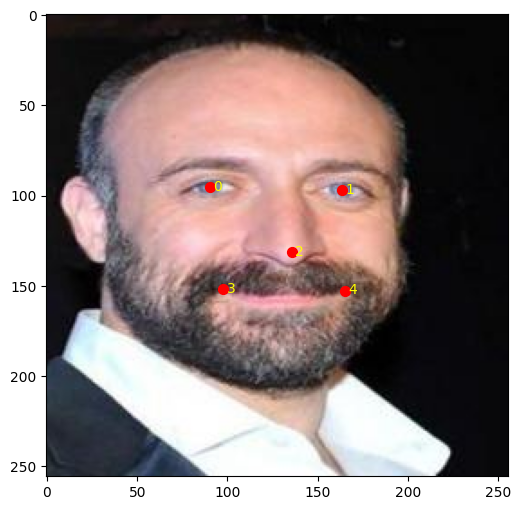

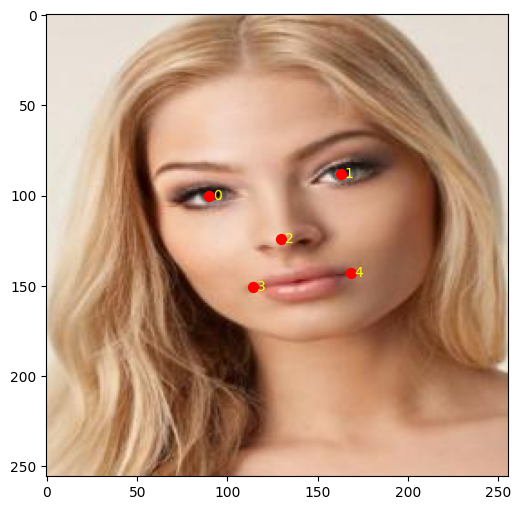

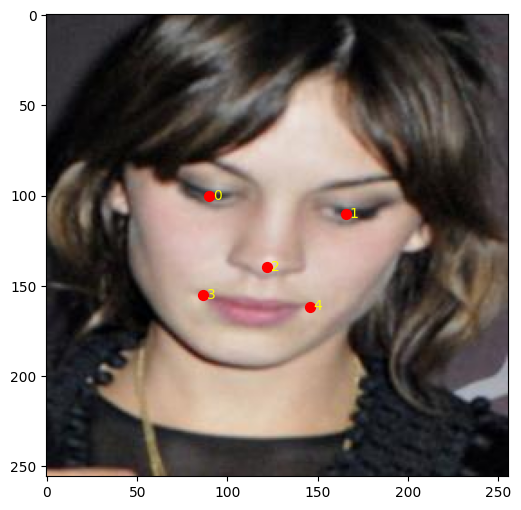

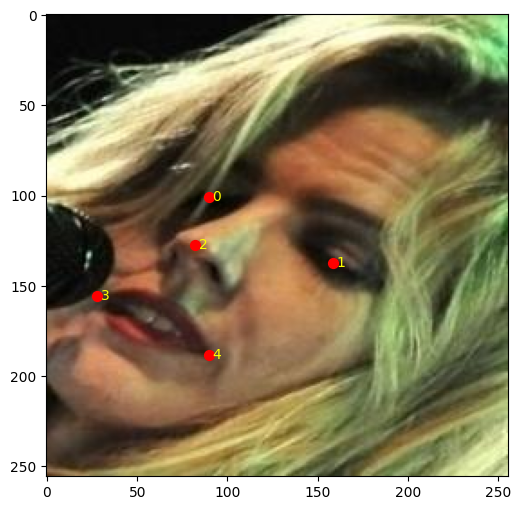

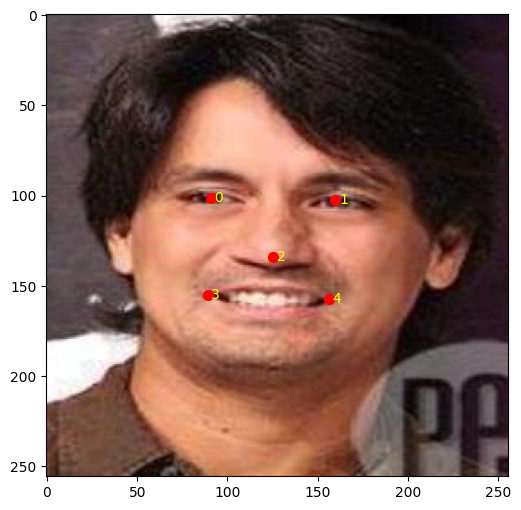

In [9]:
for i, (_, row) in enumerate(data.iterrows()):
    image_name = row["image"]
    orig = Image.open(os.path.join(IMG_DIR, image_name))
    orig_w, orig_h = orig.size

    crop = Image.open(os.path.join(OUTPUT_DIR, image_name))
# -------------------------
# параметры кропа
# -------------------------
    x, y = row["x_1"], row["y_1"]
    w, h = row["width"], row["height"]
    pad_x, pad_y = int(w * PADDING), int(h * PADDING)
    left, top = max(0, x - pad_x), max(0, y - pad_y)
    right, bottom = min(orig_w, x + w + pad_x), min(orig_h, y + h + pad_y) 
    crop_w, crop_h = (right - left), (bottom - top)
    scale_x, scale_y = IMG_SIZE / crop_w, IMG_SIZE / crop_h

# -------------------------
# координаты landmarks относительно кропа
# -------------------------
    pts = [
        ( (row["lefteye_x"] - left) * scale_x,   (row["lefteye_y"] - top) * scale_y ),
        ( (row["righteye_x"] - left) * scale_x,  (row["righteye_y"] - top) * scale_y ),
        ( (row["nose_x"] - left) * scale_x,      (row["nose_y"] - top) * scale_y ),
        ( (row["leftmouth_x"] - left) * scale_x, (row["leftmouth_y"] - top) * scale_y ),
        ( (row["rightmouth_x"] - left) * scale_x,(row["rightmouth_y"] - top) * scale_y ),
    ]

    if i < 5:
        plt.figure(figsize=(6,6)) 
        plt.imshow(crop) 
        for i, (x, y) in enumerate(pts): 
            plt.scatter(x, y, c="red", s=50) 
            plt.text(x+2, y+2, str(i), color="yellow") 
        plt.show()
# -------------------------
# Создаем heatmap 64×64    
# -------------------------
    def heatmap(xx, yy, x, y, sigma):
        return np.exp(
            -((xx - x) ** 2 + (yy - y) ** 2) / (2 * sigma ** 2)
        )
    
    heat_pts = [ # масштабируем точки ещё раз:
    (
        x * HEATMAP_SIZE / IMG_SIZE,
        y * HEATMAP_SIZE / IMG_SIZE
    )  for x, y in pts ]
    '''
для изображений 64×64 — sigma = 1–2;
для изображений 128×128 — sigma = 2–3;
для изображений 224×224 — sigma = 3–5;
для изображений 256×256 — sigma = 4–6.
    '''   
    SIGMA = 4
    heatmaps = landmarks_to_heatmaps( (HEATMAP_SIZE, HEATMAP_SIZE), heat_pts, sigma=2 )

    HEATMAP_DIR = os.path.join(ROOT, "heatmaps")
    os.makedirs(HEATMAP_DIR, exist_ok=True)
    np.save( 
        os.path.join( HEATMAP_DIR, image_name.replace(".jpg", ".npy") ), 
        heatmaps 
    )

### Проверка результата

Выбран файл: 140881.npy


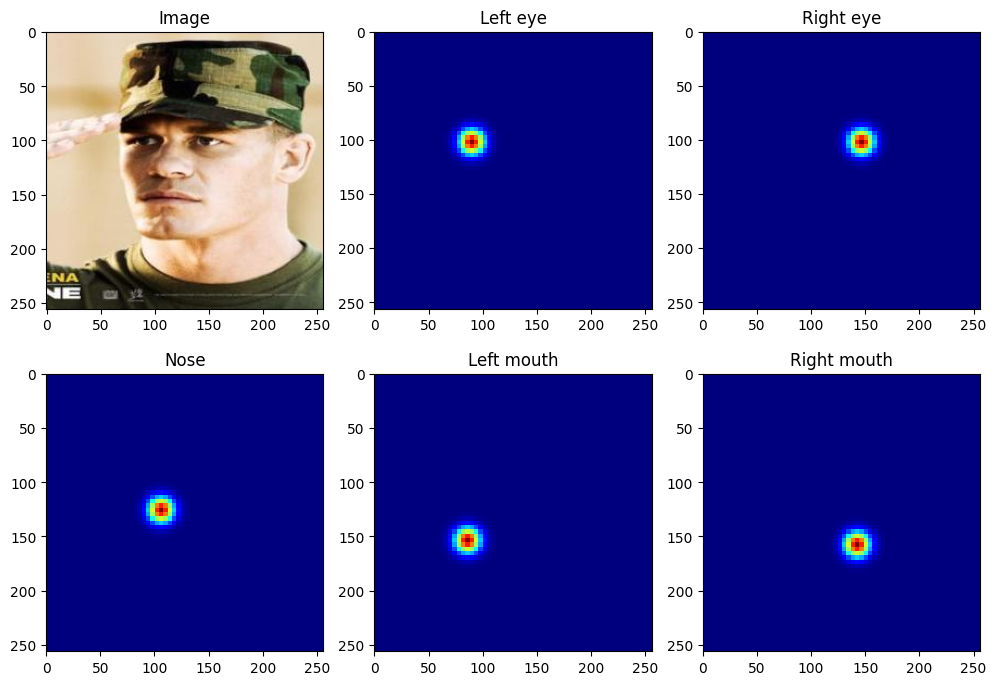

In [10]:
random_file = get_random_file("heatmaps", ".npy")
sample = np.load(random_file)
img = Image.open(f"{ROOT}/cropped_faces/{Path(random_file).stem}.jpg")

fig, ax = plt.subplots(2, 3, figsize=(10, 7))

ax[0, 0].imshow(img)
ax[0, 0].set_title("Image")

titles = [ 
    "Left eye", "Right eye",
    "Nose", 
    "Left mouth", "Right mouth"
]

for i in range(5):
    r = (i + 1) // 3
    c = (i + 1) % 3

    ax[r, c].imshow(
        sample[i],
        cmap="jet",
        interpolation="nearest",   # без сглаживания
        extent=(0, IMG_SIZE, IMG_SIZE, 0)
    )
    ax[r, c].set_xlim(0, IMG_SIZE)
    ax[r, c].set_ylim(IMG_SIZE, 0)
    ax[r, c].set_title(titles[i])

plt.tight_layout()
plt.show()

### Дополнительная проверка - наложение heatmap на изображение

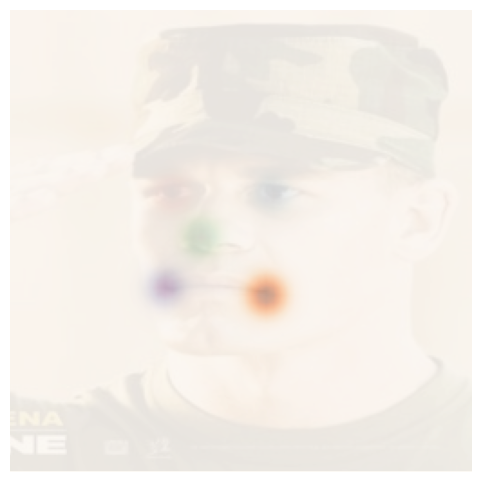

In [11]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.imshow(img)

for i, cmap in enumerate(["Reds", "Blues", "Greens", "Purples", "Oranges"]):
    ax.imshow(
        sample[i],
        cmap=cmap,
        alpha=0.4,
        extent=(0, img.width, img.height, 0),
        interpolation="bilinear",
    )

ax.set_xlim(0, img.width)
ax.set_ylim(img.height, 0)
ax.axis("off")

plt.show()

## Обучениe

## Выравнивание по предсказанным точкам

Существует множество вариантов, как по полученным точкам правильно преобразовать картинку. Главное, что вам нужно понимать - **это задача классического компьютерного зрения** и решается при помощи математики, без нейронок. Вдаваться в подробности конкретных алгоритмов мы не будем.

Можно использовать аффинное преобразование, тогда потребуется только 3 точки, можно, например, искать матрицу гомографии, где может быть использовано больше точек, а может быть, есть еще что-то. Реализовывать эти алгоритмы самим не нужно. Достаточно провести небольшой ресерч и найти готовое решение (но **не готовую нейронку для выравнивания**), лишь бы оно работало. Количество используемых точек тоже выбирайте сами, подойдет любой вариант. Условный ориентир для поиска - библиотека **opencv**. Обязательно приведите примеры того, как работает ваш алгоритм.

# План заданий

По итогу, в этом блоке у вас следующие задачи:

*   Подготовить датасет, сохранить файл с оригинальными названиями изображений
*   Реализовать Hourglass блок
*   Реализовать Stacked Hourglass
*   Преобразовать точки лица в Heatmap'ы
*   Обучить Stacked Hourglass
*   Найти функцию, которая по предсказанным ключевым точкам выравнивает лица на картинке (face alignment)
*   Подготовить датасет с кропнутыми и выровненными лицами для следующего этапа

**P.S. Не забывайте сохранять модели после обучения и выводите промежуточные результаты на экран**



**Удачи! У вас всё получится 💗!**

## Dataloader

In [43]:
class CelebALandmarksDataset(Dataset):
    def __init__(self, csv_file, image_dir, heatmap_dir):
        self.data = pd.read_csv(csv_file)
        self.image_dir = image_dir
        self.heatmap_dir = heatmap_dir
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.5,0.5,0.5],
                std=[0.5,0.5,0.5]
            )
        ])

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image_name = self.data.iloc[idx]["image"]
        image = Image.open( os.path.join( self.image_dir, image_name )).convert("RGB")
        image = self.transform(image)

        heatmap = np.load( os.path.join( self.heatmap_dir, image_name.replace(".jpg",".npy") ))
        heatmap = torch.from_numpy( heatmap ).float()

        return image, heatmap, image_name

In [44]:
dataset = CelebALandmarksDataset(CSV_OUTPUT, OUTPUT_DIR, os.path.join(ROOT,"heatmaps"))

# размеры выборок
train_size = int(0.8 * len(dataset))
valid_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - valid_size

train_dataset, valid_dataset, test_dataset = random_split(
     dataset,  
     [ train_size, valid_size, test_size ],
    generator=torch.Generator().manual_seed(42)
)

In [45]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    # num_workers=4,    # не работает на Windows
    # pin_memory=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=16,
    shuffle=False,
    # num_workers=4,    # не работает на Windows
    # pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    # num_workers=4,    # не работает на Windows
    # pin_memory=True
)

## Класс Trainer

In [ ]:
import os
import torch
import numpy as np
from tqdm.auto import tqdm

class Trainer:
    def __init__( self,  model, optimizer, criterion, device,
        scheduler=None,
        warmup_epochs=3,
        patience=10,
        grad_clip=1.0,
        save_dir="checkpoints"
    ):

        self.model = model.to(device)
        self.optimizer = optimizer
        self.criterion = criterion
        self.scheduler = scheduler
        self.device = device
        self.grad_clip = grad_clip
        self.warmup_epochs = warmup_epochs
        self.base_lr = optimizer.param_groups[0]["lr"]
        self.patience = patience
        self.best_loss = np.inf
        self.counter = 0

        self.scaler = torch.cuda.amp.GradScaler(
            enabled=torch.cuda.is_available()
        )
        self.history = {"train_loss": [], "valid_loss": [] }

        self.save_dir = save_dir
        os.makedirs(save_dir, exist_ok=True)
    ####################################################################
    ## warmup
    ####################################################################
    def warmup(self, epoch):
        if epoch >= self.warmup_epochs:
            return
        lr = self.base_lr * (epoch + 1) / self.warmup_epochs
        for group in self.optimizer.param_groups:
            group["lr"] = lr
    ####################################################################
    ## train
    ####################################################################
    def fit_epoch(self, train_loader):
        self.model.train()
        running_loss = 0
        progress = tqdm( train_loader,  leave=False, disable=True )

        for images, target in progress:
            images = images.to(self.device)
            target = target.to(self.device)
            self.optimizer.zero_grad()
            with torch.cuda.amp.autocast(
                enabled=torch.cuda.is_available()
            ):
                outputs = self.model(images)
                loss = 0
                for pred in outputs:
                    loss += self.criterion( pred, target )
            self.scaler.scale(loss).backward()
            self.scaler.unscale_(self.optimizer)
            torch.nn.utils.clip_grad_norm_(
                self.model.parameters(),
                self.grad_clip
            )
            self.scaler.step(self.optimizer)
            self.scaler.update()
            running_loss += loss.item()
            progress.set_postfix( loss=f"{loss.item():.4f}" )

        running_loss /= len(train_loader)
        return running_loss

    ####################################################################
    ## validation
    ####################################################################
    def val_epoch(self, valid_loader):
        self.model.eval()
        running_loss = 0
        with torch.no_grad():
            for images, target in valid_loader:
                images = images.to(self.device)
                target = target.to(self.device)
                outputs = self.model(images)
                loss = 0
                for pred in outputs:
                    loss += self.criterion( pred, target )
                running_loss += loss.item()

        running_loss /= len(valid_loader)
        return running_loss

    ####################################################################
    ## save
    ####################################################################
    def save_checkpoint(self, filename):
        torch.save(
            {
                "model": self.model.state_dict(),
                "optimizer": self.optimizer.state_dict(),
            },
            os.path.join( self.save_dir, filename )
        )
    ####################################################################
    ## fit
    ####################################################################
    def fit( self, train_loader, valid_loader, num_epochs=1000 ):
        for epoch in range(num_epochs):
            print(f"Epoch [{epoch+1:>{len(str(num_epochs))}}/{num_epochs}]", end=" | ")
            start_time = time.perf_counter()
            self.warmup(epoch)
            is_saved=False
            train_loss = self.fit_epoch(train_loader)
            valid_loss = self.val_epoch(valid_loader)

            if (
                self.scheduler is not None
                and epoch >= self.warmup_epochs
            ):  self.scheduler.step()
            self.history["train_loss"].append( train_loss )
            self.history["valid_loss"].append( valid_loss )

            ##############################################
            if valid_loss < self.best_loss:
                self.best_loss = valid_loss
                self.counter = 0
                self.save_checkpoint("best_model.pth")
                is_saved=True
            else:
                self.counter += 1
            
            print(
                f"TrainLoss: {train_loss:.6f}",
                f"ValidLoss: {valid_loss:.6f}",
                f"LR: {self.optimizer.param_groups[0]['lr']:.2e}",
                f"EarlyStop: {self.counter:^{len(str(self.patience))}}/{self.patience}" if self.patience >= 0 else "",
                f"EpochTime: {time.perf_counter() - start_time:.2f}s",
                f"Best Model State was Saved" if is_saved else "",
                sep=" | "
            )
            ##############################################
            # self.save_checkpoint( "last_model.pth" )   # сохранять состояние модели на каждой эпохе
            ##############################################
            if self.counter >= self.patience:
                print( "Early stopping" )
                break

        return self.history, self.model

In [34]:
# =========================
# loss curves plot
# =========================
def plot_history(history, title="Training History"):
    """
    Plots the training and validation loss curves from the training history.

    Args:
        history (dict): A dictionary containing 'train_loss' and 'valid_loss'.
        title (str): The title of the plot.
    """
    import matplotlib.pyplot as plt

    plt.figure(figsize=(8, 5))
    plt.plot(history["train_loss"], label='Train Loss')
    plt.plot(history["valid_loss"], label='Valid Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.show()

Epoch [   1/1000] | TrainLoss: 0.007968 | ValidLoss: 0.001865 | LR: 4.00e-05 | EarlyStop: 0 /10 | EpochTime: 255.69s | Best Model State was Saved
Epoch [   2/1000] | TrainLoss: 0.000964 | ValidLoss: 0.000625 | LR: 8.00e-05 | EarlyStop: 0 /10 | EpochTime: 257.83s | Best Model State was Saved
Epoch [   3/1000] | TrainLoss: 0.000515 | ValidLoss: 0.000446 | LR: 1.20e-04 | EarlyStop: 0 /10 | EpochTime: 259.58s | Best Model State was Saved
Epoch [   4/1000] | TrainLoss: 0.000401 | ValidLoss: 0.000392 | LR: 1.60e-04 | EarlyStop: 0 /10 | EpochTime: 438.50s | Best Model State was Saved
Epoch [   5/1000] | TrainLoss: 0.000339 | ValidLoss: 0.000327 | LR: 2.00e-04 | EarlyStop: 0 /10 | EpochTime: 258.83s | Best Model State was Saved
Epoch [   6/1000] | TrainLoss: 0.000293 | ValidLoss: 0.000305 | LR: 2.00e-04 | EarlyStop: 0 /10 | EpochTime: 276.26s | Best Model State was Saved
Epoch [   7/1000] | TrainLoss: 0.000266 | ValidLoss: 0.000292 | LR: 1.99e-04 | EarlyStop: 0 /10 | EpochTime: 279.38s | Best 

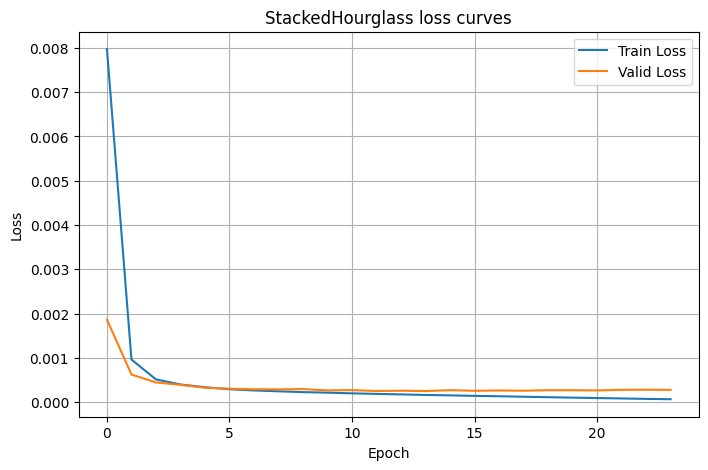

In [37]:
device = torch.device( "cuda" if torch.cuda.is_available() else "cpu" )

model = StackedHourglass (
    num_stacks=2,
    num_blocks=4,
    num_features=256,
    num_keypoints=5
)

criterion = torch.nn.MSELoss()

optimizer = torch.optim.AdamW (
    model.parameters(),
    lr=2e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR (
    optimizer,
    T_max=20,
    eta_min=1e-6
)

history, model = Trainer (
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    scheduler=scheduler,
    patience=10,
    warmup_epochs=5,
    grad_clip=1.0,
    save_dir="weightsStackedHourglass"
).fit (
    train_loader=train_loader,
    valid_loader=valid_loader,
    num_epochs=1000,
)

plot_history(history, title="StackedHourglass loss curves")


# Функция alignment
Для этого этапа нам нужен классический **face alignment** после работы **Hourglass**. Нейросеть здесь не нужна: берём предсказанные landmarks и через OpenCV строим геометрическое преобразование.

Самый распространённый вариант для лиц — аффинное преобразование по 5 точкам: левый глаз, правый глаз, нос, левый угол рта, правый угол рта.

Это ровно те 5 точек, которые уже подготовлены в heatmap = [ lefteye, righteye, nose, leftmouth, rightmouth ]

In [51]:
def heatmaps_to_points(heatmaps, image_size=256, heatmap_size=64):
    """
    heatmaps:
        Tensor [K,H,W] или [1,K,H,W]

    Возвращает:
        ndarray [K,2]
    """

    if heatmaps.ndim == 4:
        heatmaps = heatmaps.squeeze(0)

    scale = image_size / heatmap_size
    points = []
    for hm in heatmaps:
        hm = hm.detach().cpu().numpy()
        y, x = np.unravel_index( np.argmax(hm), hm.shape )
        points.append([ (x + 0.5) * scale, (y + 0.5) * scale ])

    return np.asarray(points, dtype=np.float32)

In [50]:
def align_face(img, landmarks, output_size=256):
    """
    Выравнивание лица по 5 ключевым точкам.
    """

    reference = np.array(
        [
            [70, 95],
            [186, 95],
            [128, 140],
            [82, 190],
            [174, 190]
        ],
        dtype=np.float32
    )

    matrix, _ = cv2.estimateAffinePartial2D(
        np.asarray(landmarks, dtype=np.float32),
        reference,
        method=cv2.LMEDS
    )

    if matrix is None:
        return img.copy()

    aligned = cv2.warpAffine(
        img,
        matrix,
        (output_size, output_size),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=(0, 0, 0)
    )

    return aligned

In [53]:
def align_dataset(model, dataloader, save_dir, device, image_size=256, heatmap_size=64):
    os.makedirs(save_dir, exist_ok=True)
    model.eval()
    with torch.no_grad():
        for images, _, image_names in tqdm(dataloader, disable=True):
            images = images.to(device)

            ###################################
            # Hourglass prediction
            ###################################
            outputs = model(images)
            pred_heatmaps = outputs[-1]

            ###################################
            # обработка каждого изображения
            ###################################
            for image_tensor, heatmaps, image_name in zip(images, pred_heatmaps, image_names):
                mean = np.array([0.5, 0.5, 0.5])
                std = np.array([0.5, 0.5, 0.5])

                img = image_tensor.cpu().permute(1, 2, 0).numpy()

                # денормализация
                img = img * std + mean
                img = np.clip(img, 0, 1)

                img = (img * 255).astype(np.uint8)

                points = heatmaps_to_points(
                    heatmaps,
                    image_size=image_size,
                    heatmap_size=heatmap_size
                )

                aligned = align_face(
                    img,
                    points,
                    output_size=image_size
                )

                cv2.imwrite(
                    os.path.join(save_dir, image_name),
                    cv2.cvtColor(aligned, cv2.COLOR_RGB2BGR)
                )

    print(f"Aligned dataset saved to: {save_dir}")

In [54]:
align_dataset(
    model=model,
    dataloader=test_loader,
    save_dir="data/aligned_faces",
    device=device,
    image_size=256,
    heatmap_size=64
)

Aligned dataset saved to: data/aligned_faces


# Резюме по первой части:

* Для выравнивания лица использовано аффинное преобразование OpenCV (estimateAffinePartial2D). 

* В качестве контрольных точек использованы 5 facial landmarks: два глаза, нос и два угла рта. 

* Метод не использует нейронные сети и основан на поиске матрицы преобразования, минимизирующей расстояние между предсказанными точками и заранее заданным шаблоном лица.